In [2]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (CODESPACES, SOP READY & ACADEMIC AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean narrative output.
#          2. Establish SOP Cero-Esperas persistence environment.
#          3. Connect to the Golden Master DB (pienza.db) in Codespaces.
#          4. Apply the "Opus Academic" Visual Canon for LaTeX integration.
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None

# --- 2. CORE IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# --- 3. SOP CERO-ESPERAS & IDENTITY CONFIG ---
DATE_PREFIX = "260505" # Sellado: 5 de Mayo de 2026
NOTEBOOK_ID = "0510"
FORCE_UPDATE = False   # Cambiar a True solo si necesitas recalcular todo desde cero

BASE_DIR = "/workspaces/pienza/data/"
DUMP_DIR = os.path.join(BASE_DIR, "data/dumped_files")
os.makedirs(DUMP_DIR, exist_ok=True)

print(f"📦 SOP Cero-Esperas Activado. Directorio de caché: {DUMP_DIR}")

# --- 4. CONNECTIVITY (CODESPACES LOCAL DB) ---
print("⏳ Mounting environment and connecting to local DB...")

# Apuntando al Golden Master local en Codespaces
DB_PATH = os.path.join(BASE_DIR, 'pienza.db') 

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}. Por favor verifica la ruta.")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"✅ SQL Engine Active: {DB_PATH}")

# --- 5. VISUAL CANON (OPUS ACADEMIC THEME) ---
# Strictly optimized for LaTeX: Pure white backgrounds, sharp contrast.
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_ORANGE = '#fde725'
OPUS_DARK   = '#121212'
OPUS_MUTED  = '#7A7A7A'

sns.set_theme(style="white") # No grids by default
plt.rcParams.update({
    'figure.facecolor': '#FFFFFF',
    'axes.facecolor': '#FFFFFF',
    'text.color': OPUS_DARK,
    'xtick.color': OPUS_DARK,
    'ytick.color': OPUS_DARK,
    'axes.edgecolor': '#E0E0E0',
    'axes.linewidth': 1.0,
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_DARK,
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.titlesize': 16,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Academic (LaTeX Ready).")
print("\n--- PHASE 5 ENVIRONMENT READY ---")

📦 SOP Cero-Esperas Activado. Directorio de caché: /workspaces/pienza/data/data/dumped_files
⏳ Mounting environment and connecting to local DB...
✅ SQL Engine Active: /workspaces/pienza/data/pienza.db
✅ Visual Identity Loaded: Opus Academic (LaTeX Ready).

--- PHASE 5 ENVIRONMENT READY ---


In [3]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [4]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================
import pandas as pd
from IPython.display import display

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Polygon Consolidation)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'),
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [6]:
# ==============================================================================
# CELL 1.3: MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================
import numpy as np
from IPython.display import display

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


In [7]:
# ==============================================================================
# CELL 1.3.MAP: H3 HEX-GRID VISUALIZATION (UNIVERSAL H3 COMPATIBILITY)
# ==============================================================================
try:
    import h3
except ImportError:
    !pip install h3 folium -q
    import h3

import folium
import pandas as pd
from matplotlib import cm, colors

# --- 0. CONFIGURACIÓN ---
LAT_COL = 'dropoff_lat'
LNG_COL = 'dropoff_lon'
RES = 10

print(f"📡 Columnas: {LAT_COL} | {LNG_COL}")
print("⏳ Mapeando zonas estratégicas (Buscando compatibilidad H3)...")

# --- 1. CLEANING ---
# Eliminamos el vacío 'unassigned'
df_map = df_input[df_input['final_zone_id'].str.lower() != 'unassigned'].copy()

# --- 2. H3 INDEXING (FUNCIÓN UNIVERSAL) ---
def get_hex(lat, lng, res):
    # Intentar v4 (latlng_to_cell)
    if hasattr(h3, 'latlng_to_cell'):
        return h3.latlng_to_cell(lat, lng, res)
    # Intentar v4-beta (latlng_to_h3)
    elif hasattr(h3, 'latlng_to_h3'):
        return h3.latlng_to_h3(lat, lng, res)
    # Intentar v3 (geo_to_h3)
    else:
        return h3.geo_to_h3(lat, lng, res)

df_map['h3_hex'] = df_map.apply(
    lambda row: get_hex(row[LAT_COL], row[LNG_COL], RES), axis=1
)

# --- 3. AGGREGATION ---
hex_summary = df_map.groupby('h3_hex').agg({
    'final_zone_id': lambda x: x.mode()[0],
    'final_zone_name': 'first'
}).reset_index()

# --- 4. COLOR FORGE ---
unique_zones = sorted(hex_summary['final_zone_id'].unique())
cmap = cm.get_cmap('viridis', len(unique_zones))
zone_color_map = {zone: colors.rgb2hex(cmap(i)) for i, zone in enumerate(unique_zones)}

# --- 5. MAP CONSTRUCTION ---
center_lat, center_lng = df_map[LAT_COL].mean(), df_map[LNG_COL].mean()
m = folium.Map(location=[center_lat, center_lng], zoom_start=13, tiles='CartoDB positron')

def get_geojson(hex_id, zone_id, zone_name):
    # Intentar v4 (cell_to_boundary)
    if hasattr(h3, 'cell_to_boundary'):
        boundary = h3.cell_to_boundary(hex_id)
    # Intentar v3 (h3_to_geo_boundary)
    else:
        boundary = h3.h3_to_geo_boundary(hex_id)

    return {
        "type": "Feature",
        "geometry": {
            "type": "Polygon",
            "coordinates": [[ [p[1], p[0]] for p in boundary ]]
        },
        "properties": {"zone_id": zone_id, "zone_name": zone_name}
    }

features = [get_geojson(row['h3_hex'], row['final_zone_id'], row['final_zone_name'])
            for _, row in hex_summary.iterrows()]

folium.GeoJson(
    {"type": "FeatureCollection", "features": features},
    style_function=lambda f: {
        'fillColor': zone_color_map.get(f['properties']['zone_id']),
        'color': 'black', 'weight': 0.3, 'fillOpacity': 0.6,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['zone_id', 'zone_name'],
        aliases=['zone id:', 'name:']
    )
).add_to(m)

print(f"✅ Éxito total. {len(unique_zones)} zonas mapeadas en H3 Res {RES}.")
m

📡 Columnas: dropoff_lat | dropoff_lon
⏳ Mapeando zonas estratégicas (Buscando compatibilidad H3)...
✅ Éxito total. 65 zonas mapeadas en H3 Res 10.


/tmp/ipykernel_56079/3492560306.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(unique_zones))


⏳ calculating forensic signals (mi + chi2)...


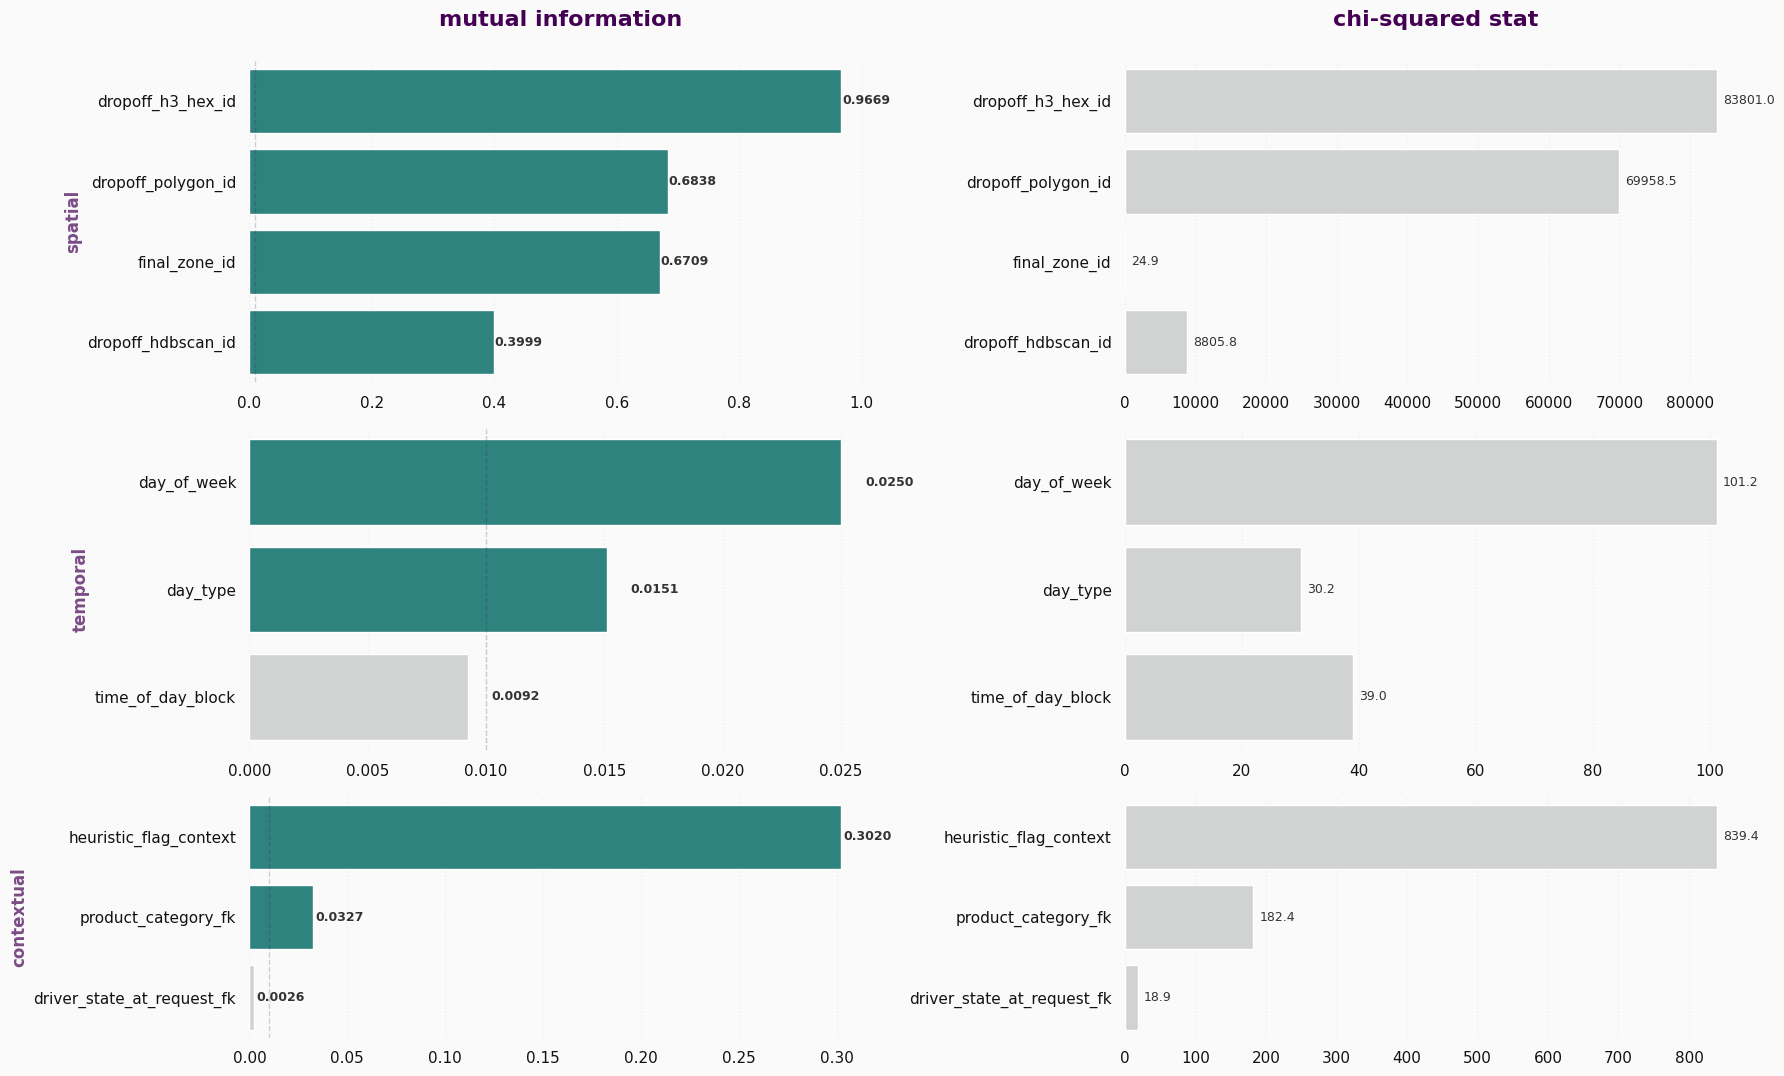

📊 summary: 8 survivors kept, 2 noise variables purged.


In [8]:
# ==============================================================================
# CELL 1.4 (PIENZA FINAL): THE CATEGORICAL FOUNDRY & ARENA (CLEAN LABELS)
# ==============================================================================
# Purpose: Dual-metric forensic audit with uniform bar thickness and clean labels.
# Final Tweaks: Removed 'arena' suffix and renamed context to contextual.
# ==============================================================================

from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. PIENZA CANONICAL COLORS (SOBER)
PIENZA_BG = "#FAFAFA"
PIENZA_TEAL = "#21918c"   # survivor (signal)
PIENZA_GRAY = "#D0D3D4"   # noise / chi2 column (neutral)
PIENZA_PURPLE = "#440154" # structure
PIENZA_TEXT = "#333333"

# --- STEP 2: MULTIVARIATE AUDIT (THE TOURNAMENT) ---
print("⏳ calculating forensic signals (mi + chi2)...")
arenas = {
    'spatial_arena':  ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id'],
    'temporal_arena': ['hour_of_day', 'day_of_week', 'time_of_day_block', 'day_type'],
    'context_arena':  ['heuristic_flag_context', 'product_category_fk', 'driver_state_at_request_fk']
}

results_list = []
for arena_name, features in arenas.items():
    for col in features:
        if col in df_input.columns:
            x_encoded = LabelEncoder().fit_transform(df_input[col].fillna("n/a").astype(str)).reshape(-1, 1)
            mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]
            c2_stat, _ = chi2(x_encoded, y)
            results_list.append({
                'Arena': arena_name, 'Feature': col, 'MI': mi, 'Chi2': c2_stat[0],
                'Status': 'survivor' if mi >= 0.01 else 'noise'
            })
df_results = pd.DataFrame(results_list)

# --- STEP 3: VISUALIZACIÓN CLÍNICA (UNIFORM BARS & CONTEXTUAL LABELS) ---
# Gridspec handles uniform pixel height for bars across 4-4-3 distributions.
fig, axes = plt.subplots(3, 2, figsize=(18, 12), facecolor=PIENZA_BG,
                         gridspec_kw={'height_ratios': [4, 4, 3]})

colors_mi = {'survivor': PIENZA_TEAL, 'noise': PIENZA_GRAY}
color_chi = PIENZA_GRAY

for i, (arena_name, row_axes) in enumerate(zip(arenas.keys(), axes)):
    subset = df_results[df_results['Arena'] == arena_name].sort_values('MI', ascending=False)

    # --- COL 0: MUTUAL INFORMATION ---
    ax_mi = row_axes[0]
    ax_mi.set_facecolor(PIENZA_BG)
    sns.barplot(data=subset, x='MI', y='Feature', hue='Status', palette=colors_mi, ax=ax_mi, dodge=False, width=0.8, legend=False)
    ax_mi.axvline(0.01, color=PIENZA_PURPLE, linestyle='--', alpha=0.2, linewidth=1)

    for p in ax_mi.patches:
        val = p.get_width()
        if val > 0.0001:
            ax_mi.text(val + 0.001, p.get_y() + p.get_height()/2, f'{val:.4f}', va='center', fontsize=9, fontweight='bold', color=PIENZA_TEXT)

    # --- COL 1: CHI-SQUARED ---
    ax_c2 = row_axes[1]
    ax_c2.set_facecolor(PIENZA_BG)
    sns.barplot(data=subset, x='Chi2', y='Feature', color=color_chi, ax=ax_c2, width=0.8)

    for p in ax_c2.patches:
        val = p.get_width()
        if val > 0.1:
            ax_c2.text(val + (subset['Chi2'].max()*0.01), p.get_y() + p.get_height()/2, f'{val:.1f}', va='center', fontsize=9, color=PIENZA_TEXT)

    # --- ROW & COLUMN STYLING ---
    for j, ax in enumerate(row_axes):
        if i == 0:
            ax.set_title(f"{'mutual information' if j==0 else 'chi-squared stat'}",
                         fontsize=16, fontweight='bold', color=PIENZA_PURPLE, pad=25)

        # Label Refinement: Delete 'arena' and rename 'context' -> 'contextual'
        if j == 0:
            clean_label = arena_name.replace('_arena', '').replace('context', 'contextual')
            ax.set_ylabel(clean_label, fontsize=12, fontweight='bold', color=PIENZA_PURPLE, alpha=0.7)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        if ax.get_legend(): ax.get_legend().remove()
        sns.despine(left=True, bottom=True, ax=ax)
        ax.grid(axis='x', color='#DDDDDD', linestyle=':', alpha=0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

# Final Summary
noise_list = df_results[df_results['Status'] == 'noise']['Feature'].tolist()
print(f"📊 summary: {len(df_results) - len(noise_list)} survivors kept, {len(noise_list)} noise variables purged.")

In [9]:
# ==============================================================================
# CELL 0: THE HISTORICAL VALIDATION LEDGER (PHASE 1-2 SUMMARY)
# ==============================================================================
import pandas as pd
from IPython.display import display, Markdown

print("📖 Loading Historical Validation Ledger...")

# Hardcoding the exact journey that led to XGBoost and LIGA B
ledger_data = {
    "Metric / Attribute": [
        "Algorithm",
        "Validation Method",
        "Target/Goal",
        "F1: LIGA A (Wide PCA)",
        "F1: LIGA B (Raw)",
        "F1: LIGA C (Praetorian PCA)",
        "Best AUC (Liga B)"
    ],
    "1. Baseline (NB Random)": [
        "Gaussian NB", "StratifiedKFold (Shuffle)", "Initial statistical signal.",
        "0.288", "0.286", "0.293", "-"
    ],
    "2. Reality Check (NB Time)": [
        "Gaussian NB", "custom_cv_folds (Chrono)", "Test fragility to Concept Drift.",
        "0.265", "0.155", "0.252", "-"
    ],
    "3. Context Fix (NB Hybrid)": [
        "Gaussian NB", "custom_cv_folds (Chrono)", "Categorical/geospatial stabilization.",
        "0.257", "0.257", "0.256", "-"
    ],
    "4. Linear Upgrade (LR Time)": [
        "Logistic Regression", "TimeSeriesSplit (Chrono)", "Map linear boundaries over time.",
        "0.482", "0.514", "0.490", "-"
    ],
    "5. State vs. Time (LR Strat)": [
        "Logistic Regression", "StratifiedKFold (Shuffle)", "Test absolute separability (Leakage).",
        "0.687", "0.716", "0.691", "0.944"
    ],
    "6. Non-Linear Scout (DT Time)": [
        "Decision Tree (Depth=7)", "TimeSeriesSplit (Chrono)", "Audit rigid non-linear rules.",
        "0.336", "0.474", "0.373", "-"
    ],
    "7. XGBoost Gym (W1-5 Strat)": [
        "XGBoost Classifier", "StratifiedKFold (Shuffle)", "Max data efficiency for stateful events.",
        "0.760", "0.761", "(Retired)", "-"
    ]
}

# Construct the DataFrame
df_ledger = pd.DataFrame(ledger_data).set_index("Metric / Attribute")

# Display with Markdown formatting for maximum impact
display(Markdown("### 🧠 THE ULTIMATE VALIDATION LEDGER: PHASE 1 TO CURRENT"))
display(Markdown("> *Note: LIGA A is Wide PCA, LIGA C is Praetorian PCA. Both ultimately lost to the uncompressed operational logic of LIGA B.*"))

# Render the table with a clean style
display(df_ledger.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'border': '1px solid black'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'left')]
}]))

print("✅ Ledger loaded into memory. Ready to proceed to Phase 3.")

📖 Loading Historical Validation Ledger...


### 🧠 THE ULTIMATE VALIDATION LEDGER: PHASE 1 TO CURRENT

> *Note: LIGA A is Wide PCA, LIGA C is Praetorian PCA. Both ultimately lost to the uncompressed operational logic of LIGA B.*

,1. Baseline (NB Random),2. Reality Check (NB Time),3. Context Fix (NB Hybrid),4. Linear Upgrade (LR Time),5. State vs. Time (LR Strat),6. Non-Linear Scout (DT Time),7. XGBoost Gym (W1-5 Strat)
Metric / Attribute,,,,,,,
Algorithm,Gaussian NB,Gaussian NB,Gaussian NB,Logistic Regression,Logistic Regression,Decision Tree (Depth=7),XGBoost Classifier
Validation Method,StratifiedKFold (Shuffle),custom_cv_folds (Chrono),custom_cv_folds (Chrono),TimeSeriesSplit (Chrono),StratifiedKFold (Shuffle),TimeSeriesSplit (Chrono),StratifiedKFold (Shuffle)
Target/Goal,Initial statistical signal.,Test fragility to Concept Drift.,Categorical/geospatial stabilization.,Map linear boundaries over time.,Test absolute separability (Leakage).,Audit rigid non-linear rules.,Max data efficiency for stateful events.
F1: LIGA A (Wide PCA),0.288,0.265,0.257,0.482,0.687,0.336,0.760
F1: LIGA B (Raw),0.286,0.155,0.257,0.514,0.716,0.474,0.761
F1: LIGA C (Praetorian PCA),0.293,0.252,0.256,0.490,0.691,0.373,(Retired)
Best AUC (Liga B),-,-,-,-,0.944,-,-


✅ Ledger loaded into memory. Ready to proceed to Phase 3.


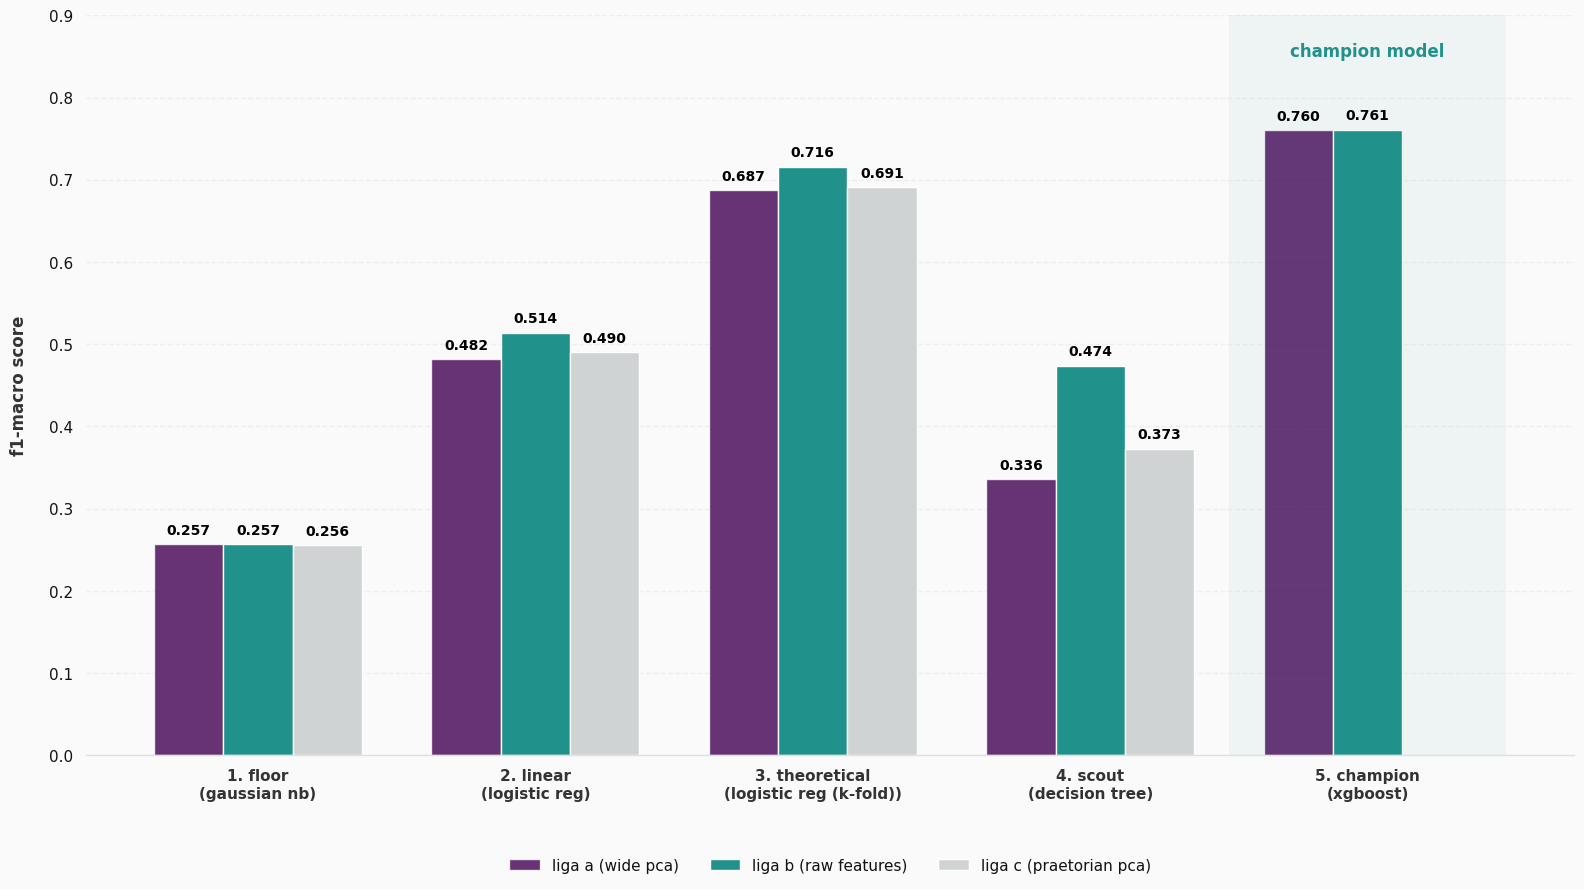

In [10]:
# ==============================================================================
# CELL: PERFORMANCE TOURNAMENT LEDGER (BAR CHART EDITION)
# ==============================================================================
# Source: LaTeX Tournament Ledger Table
# Style:  Pienza Sober - Grouped High-Density Bars
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PIENZA CANONICAL PALETTE
PIENZA_BG = "#FAFAFA"
PIENZA_TEAL = "#21918c"   # Liga B (The Champion)
PIENZA_PURPLE = "#440154" # Liga A (Structural)
PIENZA_GRAY = "#D0D3D4"   # Liga C (Contextual)
PIENZA_TEXT = "#333333"

# 2. DATA EXTRACTION FROM LATEX SOURCE
trials = ["1. floor", "2. linear", "3. theoretical", "4. scout", "5. champion"]
algorithms = ["gaussian nb", "logistic reg", "logistic reg (k-fold)", "decision tree", "xgboost"]

liga_a = [0.257, 0.482, 0.687, 0.336, 0.760]
liga_b = [0.257, 0.514, 0.716, 0.474, 0.761]
liga_c = [0.256, 0.490, 0.691, 0.373, 0.000] # 0 for Retired in plot

# 3. POSITION SETUP
x = np.arange(len(trials))
width = 0.25  # Slim bars for professional density

# 4. FIGURE ARCHITECTURE
fig, ax = plt.subplots(figsize=(16, 9), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# Plotting Groups
rects1 = ax.bar(x - width, liga_a, width, label='liga a (wide pca)', color=PIENZA_PURPLE, alpha=0.8)
rects2 = ax.bar(x, liga_b, width, label='liga b (raw features)', color=PIENZA_TEAL)
rects3 = ax.bar(x + width, liga_c, width, label='liga c (praetorian pca)', color=PIENZA_GRAY)

# 5. EXPLICIT NUMERIC LABELS (BLACK & CENTERED)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0: # Avoid labeling retired/zero values
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),  # 5 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=10, fontweight='bold', color='black')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# 6. REFINED AESTHETICS (PIENZA CLEAN)
ax.set_ylabel('f1-macro score', fontsize=12, fontweight='bold', color=PIENZA_TEXT, labelpad=15)

# X-Axis Customization (Algorithm Context)
ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n({alg})" for t, alg in zip(trials, algorithms)],
                   fontsize=11, color=PIENZA_TEXT, fontweight='bold')

# Grid & Limits
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color=PIENZA_GRAY)
ax.set_ylim(0, 0.9)

# Legend (Sober Bottom Placement)
ax.legend(frameon=False, fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

# Highlight Champion trial background
ax.axvspan(3.5, 4.5, color=PIENZA_TEAL, alpha=0.05, lw=0)
ax.text(4, 0.85, "champion model", color=PIENZA_TEAL, fontsize=12, fontweight='extra bold', ha='center')

sns.despine(left=True, bottom=False)
plt.tight_layout()

plt.show()